In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load Fertilizer Dataset
df = pd.read_csv("/content/drive/MyDrive/Coffee/Dev/C3/data/coffee_fertilizer_dataset_per_ha.csv")
df.head()

,year,month,coffee_variety,predicted_yield_kg_per_ha,soil_n,soil_p,soil_k,rainfall_mm,avg_temperature_c,growth_stage,N_kg_per_ha,P_kg_per_ha,K_kg_per_ha
0,2023,1,Arabica,1387.1,68.0,37.0,127.9,97.4,19.6,fruiting,88.4,29.5,120.5
1,2023,1,Robusta,2181.1,32.3,36.7,155.1,60.2,27.9,vegetative,210.3,44.7,123.5
2,2023,2,Arabica,1312.1,54.5,19.2,103.4,147.9,22.6,fruiting,97.5,41.5,153.3
3,2023,2,Robusta,1960.1,64.4,35.4,116.0,63.2,27.4,flowering,115.2,46.8,138.6
4,2023,3,Arabica,1665.8,47.6,18.7,119.6,68.3,27.1,post-harvest,115.9,49.2,113.5


In [4]:
# Define Features & Targets
TARGETS = ["N_kg_per_ha", "P_kg_per_ha", "K_kg_per_ha"]

FEATURES = [
    "predicted_yield_kg_per_ha",
    "soil_n",
    "soil_p",
    "soil_k",
    "rainfall_mm",
    "avg_temperature_c",
    "month",
    "growth_stage",
    "coffee_variety"
]

X = df[FEATURES]
y = df[TARGETS]


In [5]:
# Train / Validation Split
train_idx = df["year"] <= 2025
test_idx  = df["year"] == 2026

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


In [6]:
# Preprocessing (Categorical Encoding)
categorical_features = ["growth_stage", "coffee_variety"]
numeric_features = [
    col for col in FEATURES if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [7]:
# Define Multi-Output Random Forest Model
rf_base = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", MultiOutputRegressor(rf_base))
])

In [8]:
# Train the Model
model.fit(X_train, y_train)
print("Fertilizer model training complete")


Fertilizer model training complete


In [9]:
# Model Evaluation
y_pred = model.predict(X_test)

for i, nutrient in enumerate(TARGETS):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    print(f"{nutrient}")
    print(f"  MAE: {mae:.2f} kg/ha")
    print(f"  R² : {r2:.3f}\n")

N_kg_per_ha
  MAE: 12.83 kg/ha
  R² : 0.821

P_kg_per_ha
  MAE: 4.75 kg/ha
  R² : 0.848

K_kg_per_ha
  MAE: 14.56 kg/ha
  R² : 0.813



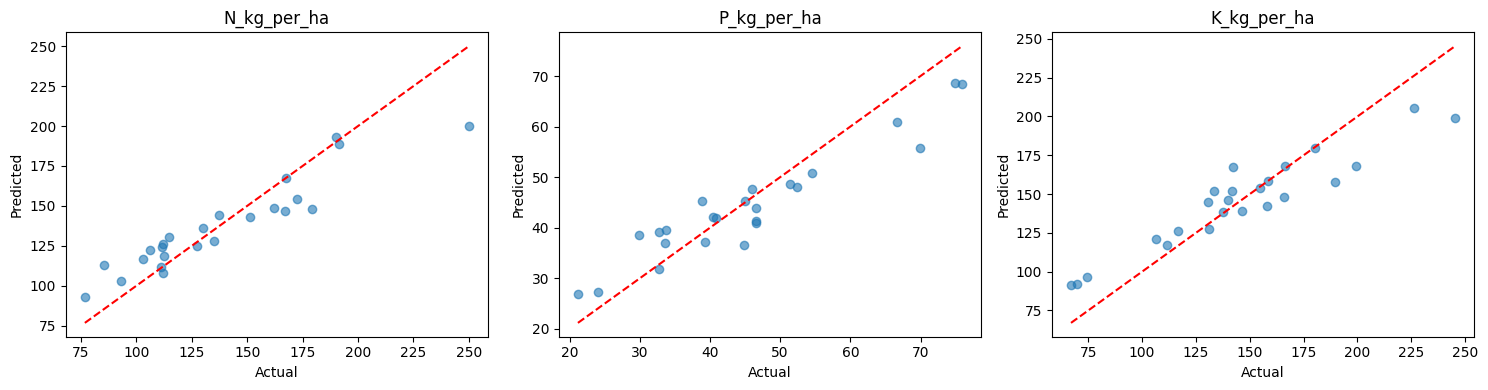

In [10]:
# Visual Check (Predicted vs Actual)
plt.figure(figsize=(15, 4))

for i, nutrient in enumerate(TARGETS):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test.iloc[:, i], y_pred[:, i], alpha=0.6)
    plt.plot(
        [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
        [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
        'r--'
    )
    plt.title(nutrient)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

In [11]:
# Feature Importance
rf_model = model.named_steps["regressor"].estimators_[0]

feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
6,num__predicted_yield_kg_per_ha,0.507248
7,num__soil_n,0.374737
10,num__rainfall_mm,0.028076
11,num__avg_temperature_c,0.025782
3,cat__growth_stage_vegetative,0.025092
2,cat__growth_stage_post-harvest,0.016603
9,num__soil_k,0.007031
12,num__month,0.006947
8,num__soil_p,0.005008
0,cat__growth_stage_flowering,0.001126


In [12]:
# Save Model
import joblib

joblib.dump(
    model,
    "/content/drive/MyDrive/Coffee/Dev/C3/fertilizer model/coffee_fertilizer_model_per_ha.pkl"
)

print("Fertilizer prediction model saved")


Fertilizer prediction model saved
